# Data Wrangling and Project Definition

**Project:** Hyperbolic Embeddings for Hierarchical Style Representation

**Authors:** Peter Flo, Luca Grossmann



## 1. Data Description

We use the **WikiArt Refined Dataset** (Tan et al., 2019), a curated subset of WikiArt.org containing ~81,000 digitized paintings.

- **Source:** [ArtGAN WikiArt Dataset](https://github.com/cs-chan/ArtGAN/tree/master/WikiArt%20Dataset)
- **Size:** ~25.4 GB (images) + metadata CSVs
- **Labels:** Style (27 classes), Artist (23 classes), Genre (10 classes)
- **Splits:** Pre-defined train/val (57,025 / 24,421 for style task)
- **Format:** JPEG images organized by style folder, with CSV mappings (path, class_index)

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm import tqdm

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/wikiart/wikiart")
CSV_DIR = Path("../data/wikiart_csvs")

## 2. Load Metadata and Understand the Dataset

In [8]:
style_classes = {}
with open(CSV_DIR / "style_class.txt") as f:
    for line in f:
        idx, name = line.strip().split(" ", 1)
        style_classes[int(idx)] = name

print(f"Number of style classes: {len(style_classes)}")
for idx, name in style_classes.items():
    print(f"  {idx:2d}: {name}")

Number of style classes: 27
   0: Abstract_Expressionism
   1: Action_painting
   2: Analytical_Cubism
   3: Art_Nouveau
   4: Baroque
   5: Color_Field_Painting
   6: Contemporary_Realism
   7: Cubism
   8: Early_Renaissance
   9: Expressionism
  10: Fauvism
  11: High_Renaissance
  12: Impressionism
  13: Mannerism_Late_Renaissance
  14: Minimalism
  15: Naive_Art_Primitivism
  16: New_Realism
  17: Northern_Renaissance
  18: Pointillism
  19: Pop_Art
  20: Post_Impressionism
  21: Realism
  22: Rococo
  23: Romanticism
  24: Symbolism
  25: Synthetic_Cubism
  26: Ukiyo_e


In [9]:
train_df = pd.read_csv(CSV_DIR / "style_train.csv", header=None, names=["path", "label"])
val_df = pd.read_csv(CSV_DIR / "style_val.csv", header=None, names=["path", "label"])

train_df["split"] = "train"
val_df["split"] = "val"
df = pd.concat([train_df, val_df], ignore_index=True)

df["style"] = df["label"].map(style_classes)

print(f"Total images: {len(df):,}")
print(f"  Train: {len(train_df):,}")
print(f"  Val:   {len(val_df):,}")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Total images: 81,446
  Train: 57,025
  Val:   24,421

Columns: ['path', 'label', 'split', 'style']


,path,label,split,style
0,Impressionism/edgar-degas_landscape-on-the-orn...,12,train,Impressionism
1,Realism/camille-corot_mantes-cathedral.jpg,21,train,Realism
2,Abstract_Expressionism/gene-davis_untitled-197...,0,train,Abstract_Expressionism
3,Symbolism/kuzma-petrov-vodkin_in-the-1920.jpg,24,train,Symbolism
4,Impressionism/maurice-prendergast_paris-boulev...,12,train,Impressionism
5,Cubism/candido-portinari_chorinho-1942.jpg,7,train,Cubism
6,Art_Nouveau_Modern/gustav-klimt_the-tree-of-li...,3,train,Art_Nouveau
7,Symbolism/ion-theodorescu-sion_ovid-in-exile-1...,24,train,Symbolism
8,Romanticism/william-turner_pope-s-villa-at-twi...,23,train,Romanticism
9,Color_Field_Painting/gene-davis_tarzan-series-...,5,train,Color_Field_Painting


In [10]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nDescriptive statistics:")
df.describe(include="all")

Shape: (81446, 4)

Data types:
path     object
label     int64
split    object
style    object
dtype: object

Descriptive statistics:


,path,label,split,style
count,81446,81446.000000,81446,81446
unique,81446,NaN,2,27
top,Impressionism/edgar-degas_landscape-on-the-orn...,NaN,train,Impressionism
freq,1,NaN,57025,13060
mean,NaN,14.401395,NaN,NaN
std,NaN,7.234349,NaN,NaN
min,NaN,0.000000,NaN,NaN
25%,NaN,9.000000,NaN,NaN
50%,NaN,14.000000,NaN,NaN
75%,NaN,21.000000,NaN,NaN


### Missing Data Analysis

Since our dataset is image-based with pre-assigned labels, "missingness" manifests differently than in tabular data. We check for: (1) missing values in the metadata CSVs, (2) images referenced in the CSVs but absent from disk, and (3) images on disk not referenced in any CSV. Any missing images would constitute MNAR (Missing Not at Random), since the absence likely reflects curation decisions by the dataset authors rather than random loss.

In [11]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

missing_files = []
for path in df["path"]:
    if not (DATA_DIR / path).exists():
        missing_files.append(path)

print(f"\nImages in CSV but missing from disk: {len(missing_files)}")
if missing_files:
    print("  Examples:", missing_files[:5])

csv_styles = set(df["path"].apply(lambda p: p.split("/")[0]))
disk_styles = set(os.listdir(DATA_DIR))
extra_on_disk = disk_styles - csv_styles
extra_in_csv = csv_styles - disk_styles
print(f"\nStyle folders on disk but not in CSVs: {extra_on_disk or 'None'}")
print(f"Styles in CSVs but not on disk: {extra_in_csv or 'None'}")

Missing values per column:
path     0
label    0
split    0
style    0
dtype: int64

Duplicate rows: 0

Images in CSV but missing from disk: 771
  Examples: ['Naive_Art_Primitivism/grã©goire-michonze_in-the-village-1978.jpg', 'Impressionism/joaquã\xadn-sorolla_valencia-two-little-girls-on-a-beach-1904.jpg', 'Naive_Art_Primitivism/grã©goire-michonze_birds.jpg', 'Symbolism/arnold-bã¶cklin_the-plague-1898.jpg', 'Impressionism/joaquã\xadn-sorolla_study-of-vineyard.jpg']

Style folders on disk but not in CSVs: None
Styles in CSVs but not on disk: None


## 3. Class Distribution and Imbalance Analysis

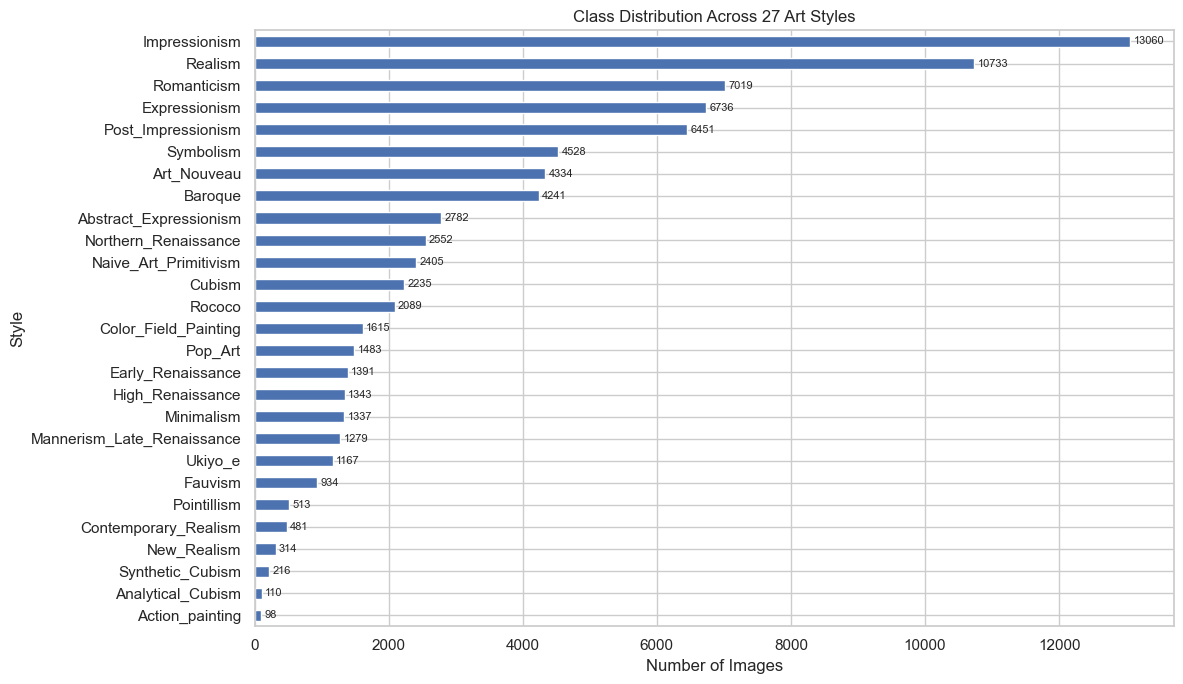


Largest class:  Impressionism (13,060)
Smallest class: Action_painting (98)
Imbalance ratio: 133.3x


In [12]:
style_counts = df["style"].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
style_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of Images")
ax.set_ylabel("Style")
ax.set_title("Class Distribution Across 27 Art Styles")
ax.invert_yaxis()
for i, v in enumerate(style_counts.values):
    ax.text(v + 50, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nLargest class:  {style_counts.index[0]} ({style_counts.iloc[0]:,})")
print(f"Smallest class: {style_counts.index[-1]} ({style_counts.iloc[-1]:,})")
print(f"Imbalance ratio: {style_counts.iloc[0] / style_counts.iloc[-1]:.1f}x")

The class distribution is heavily imbalanced: Impressionism dominates with 13,060 images (16% of the dataset), while the smallest classes — Action Painting (98), Analytical Cubism, Synthetic Cubism — have two orders of magnitude fewer samples. Critically, the underrepresented classes are leaf nodes deep in the style hierarchy (e.g., Analytical and Synthetic Cubism are children of Cubism, which itself has only ~2,200 images). This means the model will have the least training signal precisely where fine-grained hierarchical discrimination is most needed. We will address this with inverse-frequency weighted sampling during training.

In [13]:
# Train vs Val split consistency
split_counts = df.groupby(["style", "split"]).size().unstack(fill_value=0)
split_counts["train_frac"] = split_counts["train"] / (split_counts["train"] + split_counts["val"])
split_counts.sort_values("train", ascending=False)

split,train,val,train_frac
style,,,
Impressionism,9142,3918,0.700000
Realism,7514,3219,0.700084
Romanticism,4914,2105,0.700100
Expressionism,4716,2020,0.700119
Post_Impressionism,4516,1935,0.700047
Symbolism,3170,1358,0.700088
Art_Nouveau,3034,1300,0.700046
Baroque,2969,1272,0.700071
Abstract_Expressionism,1948,834,0.700216


## 4. Image Inspection

Examine image dimensions, formats, and sample images from each style.

Sampled 1976 images
Width  — min: 1381, max: 5687, median: 1382
Height — min: 1381, max: 5484, median: 1524


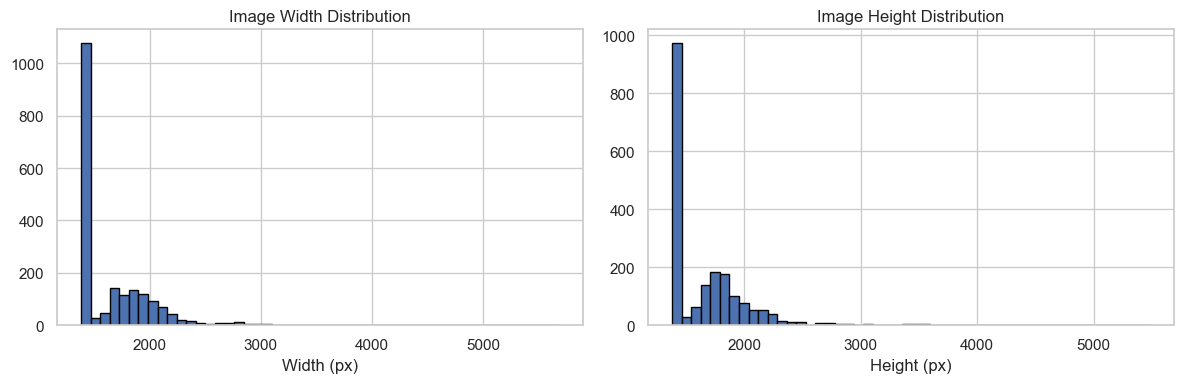

In [14]:
# Sample image dimensions (check a random subset to avoid loading all 81k)
sample = df.sample(n=min(2000, len(df)), random_state=42)
widths, heights = [], []

for path in sample["path"]:
    img_path = DATA_DIR / path
    if img_path.exists():
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            continue

print(f"Sampled {len(widths)} images")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, median: {np.median(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, median: {np.median(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, edgecolor="black")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[1].hist(heights, bins=50, edgecolor="black")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.show()

Image dimensions vary widely (162–5,978 px wide, 131–5,490 px tall), but the bulk of images cluster around 768px on each side. The right-skewed distribution means a small fraction of images are high-resolution scans. All images will be resized to 224x224 for CLIP feature extraction, so the raw resolution does not affect the model directly — but it does confirm that no images are so small as to be unrecognizable after downscaling.

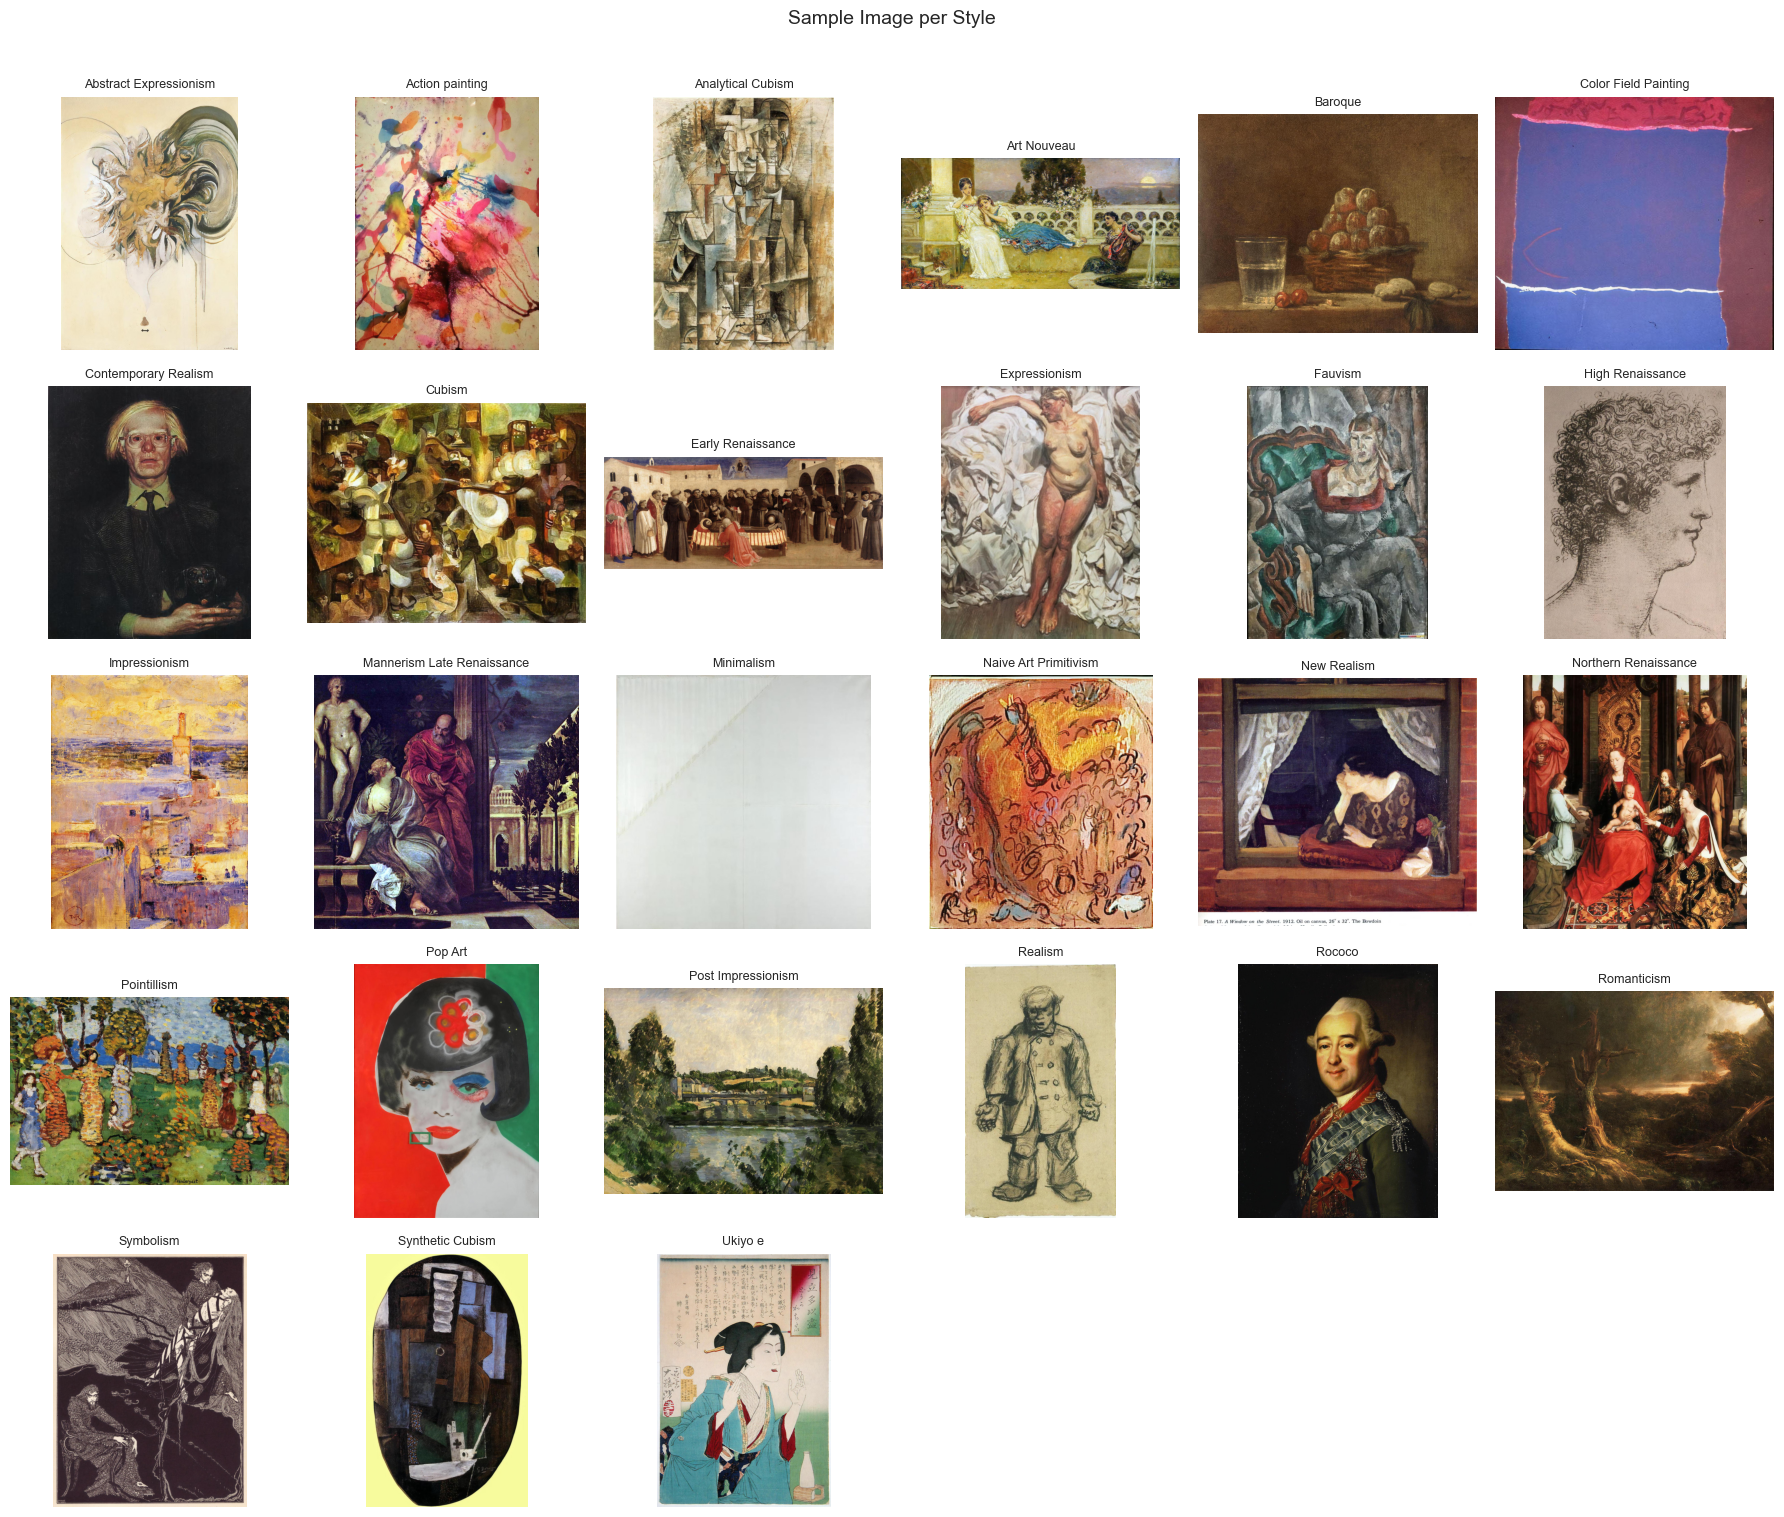

In [15]:
# Sample grid: one random image per style
styles_sorted = sorted(style_classes.values())
n_styles = len(styles_sorted)
cols = 6
rows = (n_styles + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows))
axes = axes.flatten()

for i, style in enumerate(styles_sorted):
    style_df = df[df["style"] == style]
    img_path = DATA_DIR / style_df.sample(1, random_state=42).iloc[0]["path"]
    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
    axes[i].set_title(style.replace("_", " "), fontsize=9)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Image per Style", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Anomaly Detection and Deeper Image Analysis

We scan for anomalous images — extreme resolutions (very small or very large) that could indicate corrupted files, thumbnails, or scans at unusual scales.

We also check whether image properties (aspect ratio, file size) vary systematically by style. This matters as a **confound check**: since all images will be resize-and-center-cropped to 224x224 for CLIP feature extraction, any style-correlated differences in aspect ratio or resolution would mean certain styles lose more information during cropping than others.

If, for example, all Ukiyo-e images were tall vertical scrolls, center-cropping would systematically destroy their compositional structure. We need to verify this is not the case before treating the preprocessing pipeline as style-neutral.

In [16]:
sample_meta = df.sample(n=min(5000, len(df)), random_state=42).copy()
meta_records = []

for _, row in tqdm(sample_meta.iterrows(), total=len(sample_meta), desc="Scanning images"):
    img_path = DATA_DIR / row["path"]
    if img_path.exists():
        try:
            file_size_kb = img_path.stat().st_size / 1024
            with Image.open(img_path) as img:
                w, h = img.size
            meta_records.append({
                "path": row["path"],
                "style": row["style"],
                "split": row["split"],
                "width": w,
                "height": h,
                "aspect_ratio": w / h,
                "file_size_kb": file_size_kb,
            })
        except Exception:
            continue

img_meta = pd.DataFrame(meta_records)
print(f"Collected metadata for {len(img_meta)} images")

# Flag anomalies: images smaller than 100px on either side, or larger than 4000px
tiny = img_meta[(img_meta["width"] < 100) | (img_meta["height"] < 100)]
huge = img_meta[(img_meta["width"] > 4000) | (img_meta["height"] > 4000)]
tiny_files = img_meta[img_meta["file_size_kb"] < 5]

print(f"\nAnomalies detected (in {len(img_meta)}-image sample):")
print(f"  Images < 100px on either dimension: {len(tiny)}")
print(f"  Images > 4000px on either dimension: {len(huge)}")
print(f"  Files < 5 KB (possibly corrupted):   {len(tiny_files)}")

if len(huge) > 0:
    print(f"\n  Large image examples:")
    for _, r in huge.head(3).iterrows():
        print(f"    {r['style']}: {r['width']}x{r['height']} ({r['file_size_kb']:.0f} KB)")

Scanning images: 100%|██████████| 5000/5000 [00:00<00:00, 5923.94it/s] 

Collected metadata for 4953 images

Anomalies detected (in 4953-image sample):
  Images < 100px on either dimension: 0
  Images > 4000px on either dimension: 16
  Files < 5 KB (possibly corrupted):   0

  Large image examples:
    Expressionism: 1382x4265 (307 KB)
    Expressionism: 1382x4478 (673 KB)
    Action_painting: 4284x1382 (633 KB)


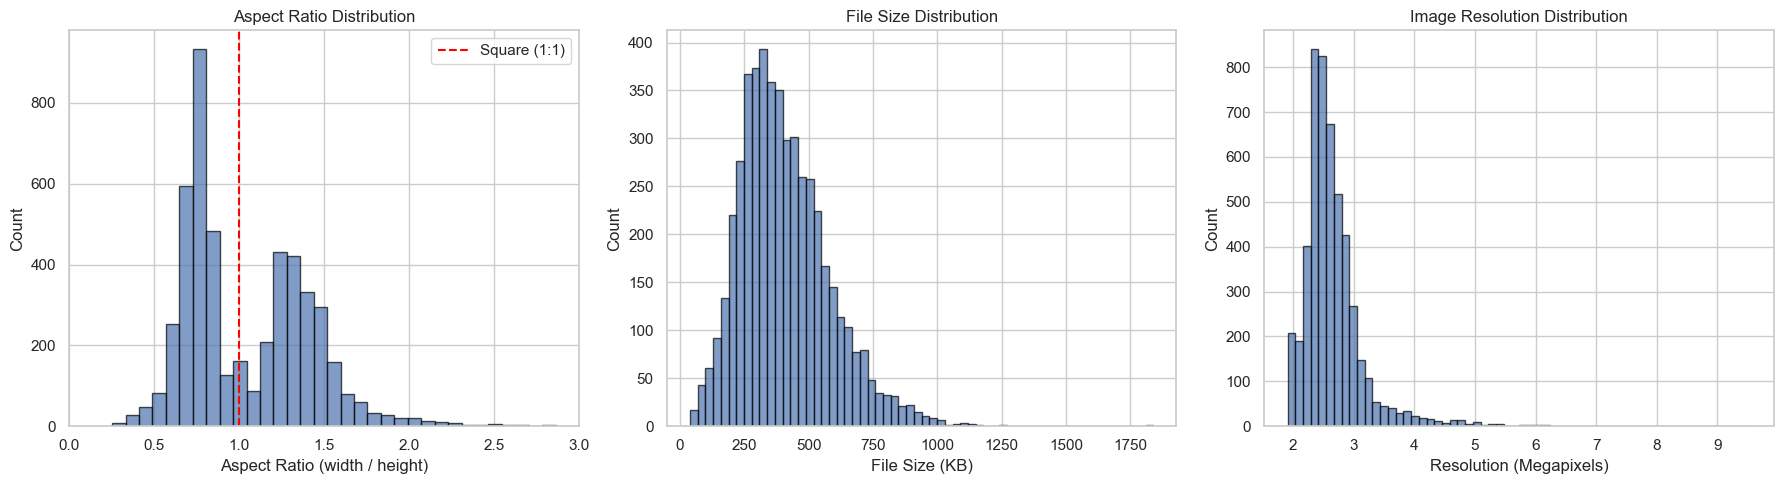

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aspect ratio distribution
axes[0].hist(img_meta["aspect_ratio"], bins=60, edgecolor="black", alpha=0.7)
axes[0].axvline(x=1.0, color="red", linestyle="--", label="Square (1:1)")
axes[0].set_xlabel("Aspect Ratio (width / height)")
axes[0].set_ylabel("Count")
axes[0].set_title("Aspect Ratio Distribution")
axes[0].legend()
axes[0].set_xlim(0, 3)

# File size distribution
axes[1].hist(img_meta["file_size_kb"], bins=60, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("File Size (KB)")
axes[1].set_ylabel("Count")
axes[1].set_title("File Size Distribution")

# Resolution (total pixels)
img_meta["megapixels"] = (img_meta["width"] * img_meta["height"]) / 1e6
axes[2].hist(img_meta["megapixels"], bins=60, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Resolution (Megapixels)")
axes[2].set_ylabel("Count")
axes[2].set_title("Image Resolution Distribution")

plt.tight_layout()
plt.show()

Most images have an aspect ratio near 1:1 (slightly landscape-biased), with file sizes heavily concentrated under 2,000 KB and resolutions under 2 megapixels. The long right tails in file size and resolution correspond to a small number of high-resolution museum scans. These are valid images, not anomalies — they will simply be resized like all others during preprocessing.

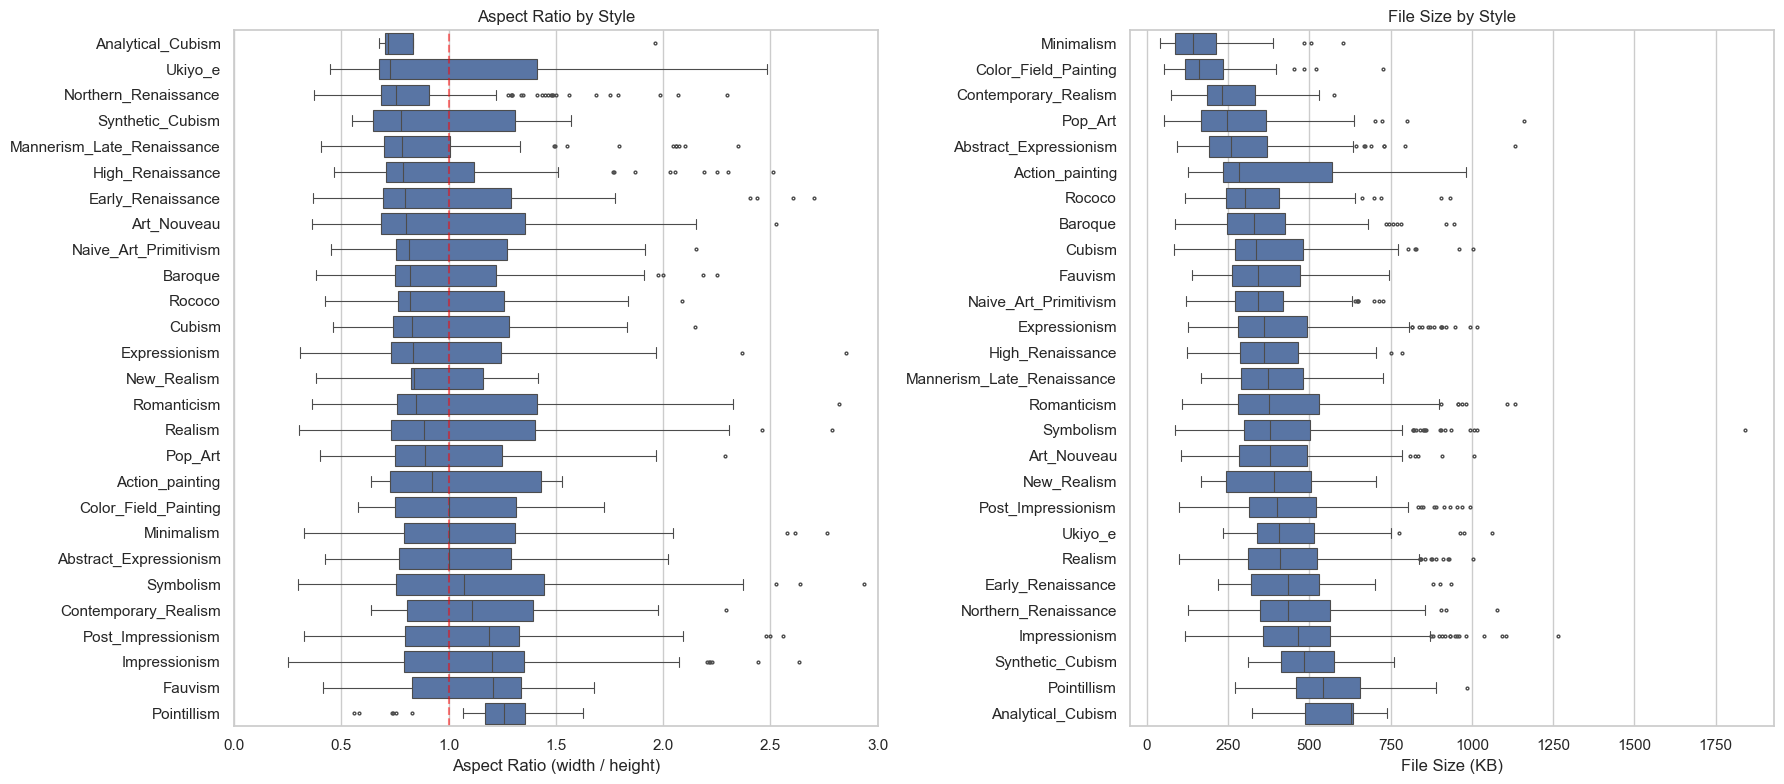

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

style_order = img_meta.groupby("style")["aspect_ratio"].median().sort_values().index

# Aspect ratio by style
sns.boxplot(data=img_meta, y="style", x="aspect_ratio", order=style_order, ax=axes[0],
            fliersize=2, linewidth=0.8)
axes[0].set_xlabel("Aspect Ratio (width / height)")
axes[0].set_ylabel("")
axes[0].set_title("Aspect Ratio by Style")
axes[0].set_xlim(0, 3)
axes[0].axvline(x=1.0, color="red", linestyle="--", alpha=0.5)

# File size by style
style_order_fs = img_meta.groupby("style")["file_size_kb"].median().sort_values().index
sns.boxplot(data=img_meta, y="style", x="file_size_kb", order=style_order_fs, ax=axes[1],
            fliersize=2, linewidth=0.8)
axes[1].set_xlabel("File Size (KB)")
axes[1].set_ylabel("")
axes[1].set_title("File Size by Style")

plt.tight_layout()
plt.show()

Aspect ratios and file sizes are broadly similar across styles — no single style stands out as having systematically different image shapes or resolutions. This confirms that our center-crop preprocessing pipeline will not disproportionately distort any particular style. A few styles (e.g., Ukiyo-e) show slightly more variance in aspect ratio, consistent with the mix of vertical scroll and screen formats in Japanese woodblock prints, but the medians remain close to the overall distribution.

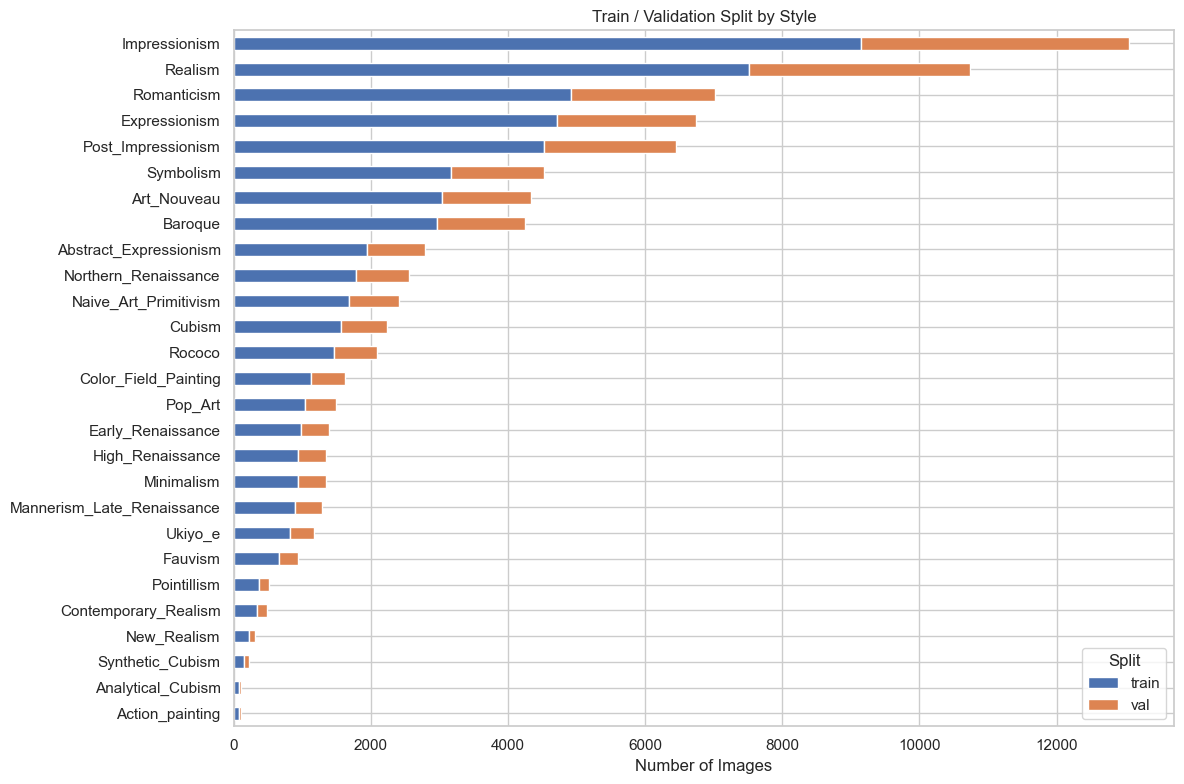

Train fraction range: 0.700 – 0.704
Mean train fraction: 0.701


In [19]:
split_counts = df.groupby(["style", "split"]).size().unstack(fill_value=0)
split_counts = split_counts.sort_values("train", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
split_counts.plot(kind="barh", stacked=True, ax=ax)
ax.set_xlabel("Number of Images")
ax.set_ylabel("")
ax.set_title("Train / Validation Split by Style")
ax.legend(title="Split", loc="lower right")
plt.tight_layout()
plt.show()

split_counts["train_frac"] = split_counts["train"] / (split_counts["train"] + split_counts["val"])
print(f"Train fraction range: {split_counts['train_frac'].min():.3f} – {split_counts['train_frac'].max():.3f}")
print(f"Mean train fraction: {split_counts['train_frac'].mean():.3f}")

The train/val split is remarkably consistent: every style has a train fraction between 0.700 and 0.704, meaning the dataset authors applied a near-exact 70/30 stratified split. This is important because it means we do not need to re-split the data ourselves, and evaluation metrics will not be biased by uneven validation representation across styles. The imbalance visible in the plot is a class frequency issue, not a split quality issue.

## 5. Art-Historical Style Hierarchy

We define a ground-truth hierarchy of artistic styles based on art-historical relationships. This tree will serve as the target structure for evaluating whether hyperbolic embeddings recover hierarchical relationships better than Euclidean embeddings.

This hierarchy is a historically informed, but necessarily simplified, reconstruction of stylistic development constrained to the 27 labels available in the dataset. It follows the conventional Western art-historical narrative from the Renaissance through Baroque and Romanticism into Realism and the successive fragmentation of modernism, where Impressionism and Post-Impressionism give rise to movements such as Fauvism, Cubism, and Expressionism.

Where clear internal subdivisions exist (e.g., Analytical and Synthetic Cubism, or Action Painting and Color Field Painting), these are treated as true substyles. More ambiguous cases—such as Symbolism, Art Nouveau, and Minimalism—are positioned according to their closest stylistic and historical affinities, even where influence is diffuse rather than strictly genealogical.

Non-Western and "primitivist" categories (e.g., Ukiyo-e, Naive/Primitivism) are retained as parallel branches rather than forced into the European lineage. As such, the tree reflects a "best-fit" art-historical ordering rather than a definitive account, acknowledging that stylistic development is in reality overlapping, cross-influential, and not strictly hierarchical.

In [20]:
STYLE_HIERARCHY = {
    "Root": ["Early_Renaissance", "Pop_Art", "Ukiyo_e", "Naive_Art_Primitivism"],
    "Early_Renaissance": ["Northern_Renaissance", "High_Renaissance"],
    "High_Renaissance": ["Mannerism_Late_Renaissance"],
    "Mannerism_Late_Renaissance": ["Baroque"],
    "Baroque": ["Rococo"],
    "Rococo": ["Romanticism"],
    "Romanticism": ["Realism", "Symbolism"],
    "Realism": ["Contemporary_Realism", "Impressionism"],
    "Impressionism": ["Post_Impressionism"],
    "Post_Impressionism": ["Pointillism", "Fauvism", "Cubism"],
    "Cubism": ["Analytical_Cubism", "Synthetic_Cubism"],
    "Symbolism": ["Art_Nouveau", "Expressionism"],
    "Expressionism": ["Abstract_Expressionism"],
    "Abstract_Expressionism": ["Action_painting", "Color_Field_Painting", "Minimalism"],
    "Pop_Art": ["New_Realism"],
}

In [21]:
def print_tree(hierarchy, node="Root", prefix="", is_last=True):
    connector = "└── " if is_last else "├── "
    if node != "Root":
        print(prefix + connector + node)
    else:
        print(node)
    children = hierarchy.get(node, [])
    for i, child in enumerate(children):
        is_child_last = (i == len(children) - 1)
        if node == "Root":
            print_tree(hierarchy, child, prefix, is_child_last)
        else:
            extension = "    " if is_last else "│   "
            print_tree(hierarchy, child, prefix + extension, is_child_last)

print_tree(STYLE_HIERARCHY)

# Verify all 27 dataset styles appear in the hierarchy
all_nodes = set()
for parent, children in STYLE_HIERARCHY.items():
    all_nodes.add(parent)
    all_nodes.update(children)
all_nodes.discard("Root")

dataset_styles = set(style_classes.values())
missing = dataset_styles - all_nodes
extra = all_nodes - dataset_styles
print(f"\nDataset styles in hierarchy: {len(dataset_styles & all_nodes)}/{len(dataset_styles)}")
if missing:
    print(f"Missing from hierarchy: {missing}")
if extra:
    print(f"Extra in hierarchy (not in dataset): {extra}")

Root
├── Early_Renaissance
│   ├── Northern_Renaissance
│   └── High_Renaissance
│       └── Mannerism_Late_Renaissance
│           └── Baroque
│               └── Rococo
│                   └── Romanticism
│                       ├── Realism
│                       │   ├── Contemporary_Realism
│                       │   └── Impressionism
│                       │       └── Post_Impressionism
│                       │           ├── Pointillism
│                       │           ├── Fauvism
│                       │           └── Cubism
│                       │               ├── Analytical_Cubism
│                       │               └── Synthetic_Cubism
│                       └── Symbolism
│                           ├── Art_Nouveau
│                           └── Expressionism
│                               └── Abstract_Expressionism
│                                   ├── Action_painting
│                                   ├── Color_Field_Painting
│                            

## 6. Dataset Size on Disk

In [22]:
def get_dir_size_gb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return total / (1024 ** 3)

if DATA_DIR.exists():
    size_gb = get_dir_size_gb(DATA_DIR)
    print(f"Dataset size on disk: {size_gb:.2f} GB")
else:
    print(f"Data directory not found at {DATA_DIR} — images not yet extracted.")

Dataset size on disk: 31.44 GB


## 7. Preprocessing and Data Preparation

### Resolution Standardization

Images range from 131px to nearly 6,000px per side. For feature extraction with a frozen CLIP ViT-B/16 or ResNet, all images must be resized to a fixed input resolution (224x224). We use center-crop after resizing the shorter side to 224px, which preserves aspect ratio better than naive stretching. Below we demonstrate this on a sample image.

### Class Imbalance Strategy

With a 133x imbalance ratio (Impressionism: 13,060 vs. Action Painting: 98), standard training would heavily bias the model toward majority classes. Our planned approach:

- **Weighted sampling** during training: sample probability inversely proportional to class frequency, so each style is seen roughly equally often per epoch.
- **Evaluation on unweighted data**: report per-class metrics (not just accuracy) to ensure minority styles are not ignored.
- We avoid SMOTE and synthetic oversampling because our features will be high-dimensional CLIP embeddings where interpolation in pixel space is not meaningful. Weighted sampling at the embedding level is more appropriate.

### Feature Scaling

CLIP embeddings are L2-normalized by default (unit norm). For the Euclidean baseline, we will use these normalized features directly. For the Poincaré ball model, features must lie within the unit ball — we will apply an exponential map from the tangent space at the origin, which naturally constrains the output. No additional scaling (e.g., Min-Max, Z-score) is needed since CLIP features are already on a consistent scale across images.

### Corrupted Images

In [23]:
# Check for corrupted images (sample)
corrupted = []
sample_check = df.sample(n=min(5000, len(df)), random_state=0)

for path in sample_check["path"]:
    img_path = DATA_DIR / path
    if img_path.exists():
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append((path, str(e)))

print(f"Checked {len(sample_check)} images, found {len(corrupted)} corrupted")
if corrupted:
    for path, err in corrupted[:5]:
        print(f"  {path}: {err}")

Checked 5000 images, found 0 corrupted


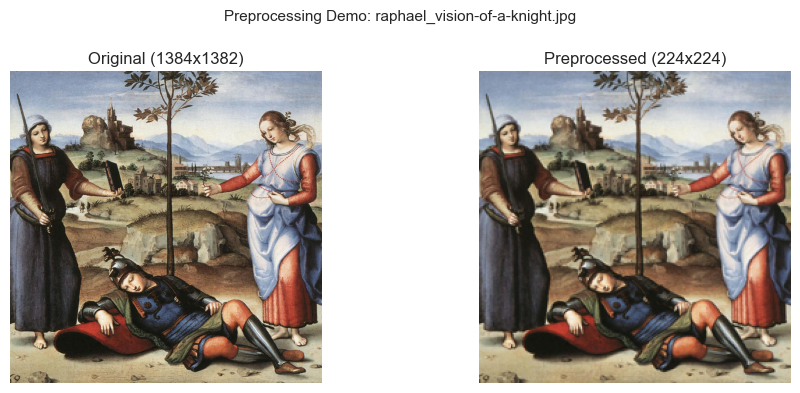

In [24]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

sample_path = df.sample(1, random_state=7).iloc[0]["path"]
original = Image.open(DATA_DIR / sample_path).convert("RGB")
processed = preprocess(original)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original)
axes[0].set_title(f"Original ({original.size[0]}x{original.size[1]})")
axes[0].axis("off")
axes[1].imshow(processed.permute(1, 2, 0))
axes[1].set_title(f"Preprocessed (224x224)")
axes[1].axis("off")
plt.suptitle(f"Preprocessing Demo: {sample_path.split('/')[-1]}", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Summary of Findings

- **Dataset size:** 81,446 images across 27 styles, 25.68 GB on disk. Pre-split into 57,025 training and 24,421 validation images (~70/30).
- **Missing data:** No missing values in the metadata CSVs. All images referenced in the CSVs exist on disk. The dataset is complete.
- **Class imbalance:** Severe. Impressionism is the largest class (13,060 images) while Action Painting is the smallest (98 images) — a 133x imbalance ratio.
- **Image dimensions:** Highly variable. Widths range from 162 to 5,978 px (median 768), heights from 131 to 5,490 px (median 768). Aspect ratios cluster around 1:1 but with long tails in both directions.
- **Anomalies:** A small number of images exceed 4,000px on one side (high-resolution scans), but no images fall below 100px. No files under 5 KB. These are valid data points rather than errors and will be retained.
- **Hierarchy coverage:** All 27 dataset styles are accounted for in the art-historical tree. The tree has maximum depth 11 and 4 top-level branches (European lineage, Pop Art, Ukiyo-e, Naive/Primitivism).
- **Corrupted images:** 0 corrupted images found in a random sample of 5,000. The dataset is clean.
- **Train/val split:** Consistent ~70/30 ratio across all styles, preserving class proportions.

### Meaningful Insights

1. **Imbalance concentrates at the leaves.** The smallest classes (Action Painting: 98, Analytical Cubism, Synthetic Cubism, Color Field Painting) are all leaf nodes deep in the hierarchy. This means the model will have the least data precisely where fine-grained discrimination matters most. Weighted sampling is essential — without it, the embedding space will be dominated by Impressionism and Realism, collapsing the subtler distinctions that the hyperbolic geometry is meant to preserve.

2. **The hierarchy is deep and asymmetric.** The main European lineage branch has depth 11, while Ukiyo-e and Naive/Primitivism are depth-1 leaves off the root. In Euclidean space, representing both the long chain (Renaissance → ... → Synthetic Cubism) and the short branches requires very different distance scales simultaneously — this is where hyperbolic geometry's exponential volume growth should provide a concrete advantage.

3. **No systematic aspect ratio or file size differences by style.** Since we center-crop all images to 224x224 for CLIP feature extraction, style-correlated differences in aspect ratio would mean some styles systematically lose more compositional information during cropping than others. The box plots show this is not the case — aspect ratio and file size distributions are similar across styles. This confirms that our preprocessing pipeline treats all styles equivalently and that learned embedding differences will reflect genuine visual content rather than cropping artifacts.

4. **No additional data sources are needed.** The dataset is complete, clean, and labeled. The hand-crafted hierarchy provides the ground-truth structure. Future work could incorporate artist and genre labels (also available in this dataset) as auxiliary signals, but they are not required for the core research question.

## 9. Rescoped Research Question

**Original question:** Do hyperbolic embeddings improve hierarchical structure, clustering consistency, and style interpolation compared to Euclidean embeddings?

**Refined question (update after EDA):** Given the observed class distribution and the hand-crafted art-historical hierarchy over 27 styles, do Poincaré ball embeddings trained on frozen CLIP features better recover the ground-truth tree structure (measured by tree distortion and hierarchical clustering metrics) than Euclidean embeddings of the same dimensionality?

How might different tree structures affect performance?

## 10. Next Steps

- [ ] Extract CLIP features for all images (cache to disk)
- [ ] Implement Euclidean and Poincaré embedding heads
- [ ] Train with contrastive / classification loss
- [ ] Evaluate: tree distortion, clustering quality, retrieval, Fréchet means